# Validación Cruzada Estratificada para KGE

Implementación de un esquema de validación cruzada k-fold estratificada sobre grafos de conocimiento (KGs).  
La estratificación se realiza por **tipo de relación**, garantizando que cada fold mantenga la distribución relacional del dataset original.  

## 1. Imports

In [3]:
import os
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
from tabulate import tabulate

## 2. Carga del dataset

Se carga el dataset de tripletas `(sujeto, relación, objeto)` directamente desde GitHub en formato CSV separado por `;`.  
Se imprime una muestra, el número total de tripletas y los nombres de columnas para verificar la carga.

In [4]:
url = "https://raw.githubusercontent.com/Londad99/Stratified-Cross-Validation/main/datasets/GoT.csv"
df = pd.read_csv(url, sep=';')

print(df.head())
print(df.shape)
print(df.columns)

                        Column1      Column2  \
0                     Smithyton      SEAT_OF   
1  House Mormont of Bear Island       LED_BY   
2               Margaery Tyrell       SPOUSE   
3         Maron Nymeros Martell  ALLIED_WITH   
4  House Gargalen of Salt Shore    IN_REGION   

                             Column3  
0         House Shermer of Smithyton  
1                      Maege Mormont  
2                  Joffrey Baratheon  
3  House Nymeros Martell of Sunspear  
4                              Dorne  
(3225, 3)
Index(['Column1', 'Column2', 'Column3'], dtype='str')


## 3. Deduplicación de tripletas

Se eliminan filas duplicadas considerando las tres columnas `(sujeto, relación, objeto)`.  
Tripletas repetidas sesgarían la distribución de los folds y contaminarían la evaluación.

In [5]:
n_antes = len(df)

df = df.drop_duplicates(
    subset=[df.columns[0], df.columns[1], df.columns[2]]
).reset_index(drop=True)

n_despues = len(df)
print(f"Tripletas antes de deduplicar : {n_antes}")
print(f"Tripletas después de deduplicar: {n_despues}")
print(f"Duplicados eliminados          : {n_antes - n_despues}")

Tripletas antes de deduplicar : 3225
Tripletas después de deduplicar: 3176
Duplicados eliminados          : 49


## 4. Estrategia de etiquetado por relación

Cada tripleta recibe una **etiqueta de estrato** igual al tipo de relación (`r`).  
Esto permite que el particionamiento Round Robin distribuya uniformemente cada relación entre los k folds.

La función `label_entities_by_relation` (conservada para referencia) clasificaba entidades por heurística;  
se reemplazó por `triple_label_for_stratification`, que usa directamente el campo de relación.

In [6]:
def label_entities_by_relation(subject, relation, obj):
    """Clasifica (sujeto, objeto) según el tipo semántico de la relación. Conservada para referencia."""
    rel_map = {
        "ALLIED_WITH": ("Casa", "Casa"),
        "BRANCH_OF":   ("Casa", "Casa"),
        "FOUNDED_BY":  ("Casa", "Persona"),
        "HEIR_TO":     ("Persona", "Persona"),
        "IN_REGION":   ("Casa", "Región"),
        "LED_BY":      ("Casa", "Persona"),
        "PARENT_OF":   ("Persona", "Persona"),
        "SEAT_OF":     ("Seat", "Casa"),
        "SPOUSE":      ("Persona", "Persona"),
        "SWORN_TO":    ("Casa", "Casa")
    }
    if relation in rel_map:
        return rel_map[relation]

    def heuristic_label(entity):
        if not isinstance(entity, str):
            return "Unknown"
        e = entity.strip()
        if e.startswith("House"):
            return "Casa"
        parts = e.split()
        if len(parts) == 0:
            return "Unknown"
        if parts[0].lower() == "the":
            return "Región"
        if len(parts) <= 3:
            all_cap = all(p and p[0].isupper() for p in parts)
            if all_cap:
                return "Persona"
        return "Unknown"

    return heuristic_label(subject), heuristic_label(obj)


def triple_label_for_stratification(subject, relation, obj):
    """Etiqueta de estrato: tipo de relación de la tripleta."""
    return relation


print("Distribución de relaciones (dataset deduplicado):")
print(df.iloc[:, 1].value_counts().to_string())

Distribución de relaciones (dataset deduplicado):
Column2
ALLIED_WITH    1517
IN_REGION       437
SWORN_TO        397
SEAT_OF         243
SPOUSE          198
LED_BY          179
PARENT_OF        60
HEIR_TO          59
FOUNDED_BY       43
BRANCH_OF        42


## 5. Particionamiento estratificado k-fold (Round Robin)

Las tripletas se agrupan por relación y se distribuyen en `k` folds mediante **Round Robin** tras barajado aleatorio reproducible.  
Esto garantiza que cada fold reciba aproximadamente `1/k` de las tripletas de cada tipo de relación.

In [7]:
def create_stratified_partitions_by_triple(triples_df, k_folds=5, random_seed=42):
    np.random.seed(random_seed)
    triples = list(triples_df.itertuples(index=False, name=None))

    grouped       = defaultdict(list)
    triple_labels = {}

    for s, r, o in triples:
        lbl = triple_label_for_stratification(s, r, o)
        grouped[lbl].append((s, r, o))
        triple_labels[(s, r, o)] = lbl

    folds = [[] for _ in range(k_folds)]
    for lbl, tlist in grouped.items():
        tcopy = tlist.copy()
        np.random.shuffle(tcopy)
        for idx, triple in enumerate(tcopy):
            folds[idx % k_folds].append(triple)

    return folds, triple_labels


k_folds = 5
folds, triple_labels = create_stratified_partitions_by_triple(
    df, k_folds=k_folds, random_seed=42
)

fold_sizes = [(i + 1, len(folds[i])) for i in range(k_folds)]
print("Folds creados (cada tripleta en exactamente un fold):")
print(tabulate(fold_sizes, headers=["Fold", "Tamaño"], tablefmt="github"))

Folds creados (cada tripleta en exactamente un fold):
|   Fold |   Tamaño |
|--------|----------|
|      1 |      640 |
|      2 |      639 |
|      3 |      635 |
|      4 |      632 |
|      5 |      630 |


## 5b. Justificación de la cantidad de datos por escenario

La elección de `k=5` folds y del tamaño de cada partición se fundamenta en tres criterios cuantitativos:

| Criterio | Descripción | Umbral deseable |
|---|---|---|
| **Desviación estándar (Std)** | Variación del recuento de tripletas de cada relación entre folds. Std ≈ 0 indica distribución perfecta. | Std < 2 por relación |
| **Coeficiente de variación (CV)** | Normaliza la Std respecto a la media; permite comparar relaciones de distinto volumen. | CV < 5% |
| **Proporción train/test** | Con k=5, el 80% de los datos entrena y el 20% prueba en cada iteración — balance estándar en la literatura KGE (FB15k, WN18). | 80 / 20 |

La tabla siguiente cuantifica la **estabilidad de la estratificación** para cada tipo de relación.

In [8]:
relation_types = sorted(df.iloc[:, 1].dropna().unique())

table_rows = []
header = ["Relación", "Total"] + [f"Fold {i+1}" for i in range(k_folds)] + ["Media", "Std", "CV (%)"]

for rel in relation_types:
    total  = int((df.iloc[:, 1] == rel).sum())
    counts = [sum(1 for t in fold if t[1] == rel) for fold in folds]
    mean   = np.mean(counts)
    std    = np.std(counts)
    cv     = (std / mean * 100) if mean > 0 else 0.0
    table_rows.append([rel, total] + counts + [f"{mean:.1f}", f"{std:.2f}", f"{cv:.1f}%"])

print("Distribución por relación y fold — Justificación de la cantidad de datos")
print("=" * 100)
print(tabulate(table_rows, headers=header, tablefmt="github"))

# Métricas globales de tamaño de folds
fold_sizes  = [len(f) for f in folds]
global_std  = np.std(fold_sizes)
global_cv   = global_std / np.mean(fold_sizes) * 100
max_cv_row  = max(table_rows, key=lambda r: float(str(r[-1]).strip('%')))

print(f"\nTamaño de folds: {fold_sizes}")
print(f"  Media : {np.mean(fold_sizes):.1f}  |  Std : {global_std:.2f}  |  CV : {global_cv:.2f}%")

print(f"\nJustificación de la elección k={k_folds}:")
print(f"  • El dataset tiene {sum(fold_sizes):,} tripletas únicas. Con k=5, cada fold de test")
print(f"    contiene ~{int(np.mean(fold_sizes))} tripletas, suficiente para una estimación estable de MRR y Hits@K.")
print(f"  • CV global del tamaño de folds = {global_cv:.2f}% (< 1%), confirmando que el")
print(f"    particionamiento Round Robin estratificado distribuye los datos de forma casi perfecta.")
print(f"  • La relación más variable es '{max_cv_row[0]}' (total={max_cv_row[1]}, CV={max_cv_row[-1]}),")
print(f"    esperado cuando el total no es divisible exactamente entre {k_folds}.")
print(f"  • La proporción entrenamiento/prueba de {(k_folds-1)*100//k_folds}%/{100//k_folds}% sigue el estándar")
print(f"    de benchmarks KGE (FB15k-237, WN18RR) para un trade-off sesgo-varianza óptimo.")

Distribución por relación y fold — Justificación de la cantidad de datos
| Relación    |   Total |   Fold 1 |   Fold 2 |   Fold 3 |   Fold 4 |   Fold 5 |   Media |   Std | CV (%)   |
|-------------|---------|----------|----------|----------|----------|----------|---------|-------|----------|
| ALLIED_WITH |    1517 |      304 |      304 |      303 |      303 |      303 |   303.4 |  0.49 | 0.2%     |
| BRANCH_OF   |      42 |        9 |        9 |        8 |        8 |        8 |     8.4 |  0.49 | 5.8%     |
| FOUNDED_BY  |      43 |        9 |        9 |        9 |        8 |        8 |     8.6 |  0.49 | 5.7%     |
| HEIR_TO     |      59 |       12 |       12 |       12 |       12 |       11 |    11.8 |  0.4  | 3.4%     |
| IN_REGION   |     437 |       88 |       88 |       87 |       87 |       87 |    87.4 |  0.49 | 0.6%     |
| LED_BY      |     179 |       36 |       36 |       36 |       36 |       35 |    35.8 |  0.4  | 1.1%     |
| PARENT_OF   |      60 |       12 |       12 |

## 6. Verificación de los folds

Se comprueba que:
- **Ninguna tripleta aparece en más de un fold** (sin overlap exacto).
- La distribución de relaciones por fold es proporcional al dataset completo.
- Se reporta el número de entidades compartidas entre pares de folds (overlap de entidades es esperado en KGs).

In [9]:
def fold_summary_and_checks(folds, triple_labels):
    summaries          = []
    fold_entities_sets = []
    fold_objects_sets  = []

    for i, fold in enumerate(folds):
        lbl_counts    = Counter([triple_labels[t] for t in fold])
        objects       = [o for (_, _, o) in fold]
        obj_counter   = Counter(objects)
        repeated_objs = [obj for obj, cnt in obj_counter.items() if cnt > 1]
        relations     = [r for (_, r, _) in fold]
        rel_counter   = Counter(relations)
        subjects      = [s for (s, _, _) in fold]
        entities      = set(subjects) | set(objects)

        summaries.append({
            "fold":                   i + 1,
            "by_label":               dict(lbl_counts),
            "repeated_objects_count": len(repeated_objs),
            "some_repeated_objects":  repeated_objs[:8],
            "unique_relations":       len(rel_counter),
            "relation_freq_sample":   list(rel_counter.items())[:8]
        })
        fold_entities_sets.append(entities)
        fold_objects_sets.append(set(objects))

    common_entities = []
    for i in range(len(folds)):
        for j in range(i + 1, len(folds)):
            commons_ent = fold_entities_sets[i] & fold_entities_sets[j]
            common_entities.append({
                "pair":         f"{i+1}-{j+1}",
                "common_count": len(commons_ent),
                "sample":       list(commons_ent)[:5]
            })

    seen     = {}
    overlaps = []
    for i, fold in enumerate(folds):
        for t in fold:
            if t in seen:
                overlaps.append({"triple": t, "first_fold": seen[t] + 1, "second_fold": i + 1})
            else:
                seen[t] = i

    return summaries, common_entities, overlaps


summaries, common_entities, overlaps = fold_summary_and_checks(folds, triple_labels)

print(f"Overlap exacto de triples entre folds: {len(overlaps)}")
if overlaps:
    print("  Aún hay duplicados — revisar el CSV original")
else:
    print("  Sin overlap — cada tripleta está en exactamente un fold")

print()
for s in summaries:
    print(f"Fold {s['fold']}:")
    for rel, cnt in sorted(s["by_label"].items(), key=lambda x: str(x[0])):
        print(f"  {rel:<15}: {cnt}")
    print(f"  Relaciones únicas: {s['unique_relations']}")

print()
print("Entidades comunes entre pares de folds (muestra):")
for ce in common_entities[:5]:
    print(f"  Par {ce['pair']}: {ce['common_count']} entidades comunes")

Overlap exacto de triples entre folds: 0
  Sin overlap — cada tripleta está en exactamente un fold

Fold 1:
  ALLIED_WITH    : 304
  BRANCH_OF      : 9
  FOUNDED_BY     : 9
  HEIR_TO        : 12
  IN_REGION      : 88
  LED_BY         : 36
  PARENT_OF      : 12
  SEAT_OF        : 49
  SPOUSE         : 40
  SWORN_TO       : 80
  nan            : 1
  Relaciones únicas: 11
Fold 2:
  ALLIED_WITH    : 304
  BRANCH_OF      : 9
  FOUNDED_BY     : 9
  HEIR_TO        : 12
  IN_REGION      : 88
  LED_BY         : 36
  PARENT_OF      : 12
  SEAT_OF        : 49
  SPOUSE         : 40
  SWORN_TO       : 80
  Relaciones únicas: 10
Fold 3:
  ALLIED_WITH    : 303
  BRANCH_OF      : 8
  FOUNDED_BY     : 9
  HEIR_TO        : 12
  IN_REGION      : 87
  LED_BY         : 36
  PARENT_OF      : 12
  SEAT_OF        : 49
  SPOUSE         : 40
  SWORN_TO       : 79
  Relaciones únicas: 10
Fold 4:
  ALLIED_WITH    : 303
  BRANCH_OF      : 8
  FOUNDED_BY     : 8
  HEIR_TO        : 12
  IN_REGION      : 87
  LED_BY 

## 7. Exportar particiones a Excel

Cada fold se guarda en una hoja separada del archivo `.xlsx`, con columnas `Subject`, `Relation`, `Object` y `label`.  
El archivo se descarga automáticamente desde Colab.

In [8]:
output_name = "folds_partitions_corregido.xlsx"
with pd.ExcelWriter(output_name) as writer:
    for i, fold in enumerate(folds, start=1):
        df_fold = pd.DataFrame(fold, columns=["Subject", "Relation", "Object"])
        df_fold["label"] = df_fold.apply(
            lambda r: triple_labels[(r["Subject"], r["Relation"], r["Object"])],
            axis=1
        )
        df_fold.to_excel(writer, sheet_name=f"Fold_{i}", index=False)

print("Guardado en:", output_name)
files.download(output_name)

Guardado en: folds_partitions_corregido.xlsx


NameError: name 'files' is not defined

## 8. Funciones de evaluación con ranking filtrado

`compute_filtered_ranks` calcula el rango de cada tripleta de prueba corrupting sujeto u objeto con todas las entidades del grafo, excluyendo tripletas verdaderas conocidas (**filtered setting** estándar en KGE).  
`compute_metrics_from_ranks` agrega los rangos en MRR, Hits@1, Hits@3 y Hits@10.

In [10]:
def compute_filtered_ranks(test_triples, entities_list, score_fn, corrupt_side, filter_triples):
    ranks = []
    for s, r, o in test_triples:
        true_score       = score_fn(s, r, o)
        candidate_scores = []

        for entity in entities_list:
            if corrupt_side == "subject":
                corrupted = (entity, r, o)
            elif corrupt_side == "object":
                corrupted = (s, r, entity)
            else:
                continue

            if corrupted not in filter_triples:
                candidate_scores.append(score_fn(*corrupted))

        all_scores = sorted(candidate_scores + [true_score], reverse=True)
        ranks.append(all_scores.index(true_score) + 1)

    return ranks


def compute_metrics_from_ranks(ranks):
    if not ranks:
        return {"MRR": 0.0, "Hits@1": 0.0, "Hits@3": 0.0, "Hits@10": 0.0}

    mrr = hits1 = hits3 = hits10 = 0
    for rank in ranks:
        mrr += 1.0 / rank
        if rank <= 1:  hits1  += 1
        if rank <= 3:  hits3  += 1
        if rank <= 10: hits10 += 1

    n = len(ranks)
    return {
        "MRR":     mrr   / n,
        "Hits@1":  hits1 / n,
        "Hits@3":  hits3 / n,
        "Hits@10": hits10 / n
    }

## 9. Evaluación k-fold con modelo KGE

En cada iteración, los `k-1` folds restantes forman el conjunto de entrenamiento y el fold `i` es el conjunto de prueba.  
Al final se promedian las métricas de todos los folds.

> **Para conectar un modelo real:** reemplaza el `score_fn` placeholder por la función de puntuación del modelo entrenado.  
> Ejemplo con AmpliGraph (`TransE`):
> ```python
> from ampligraph.latent_features import TransE
> model = TransE(batches_count=100, epochs=200, k=100, eta=5,
>                optimizer='adam', optimizer_params={'lr': 1e-3},
>                loss='pairwise', regularizer='LP',
>                regularizer_params={'p': 3, 'lambda': 1e-5}, verbose=True)
> model.fit(np.array(train_triples))
> score_fn = lambda s, r, o: float(model.predict(np.array([[s, r, o]]))[0])
> ```

In [12]:
entities_list   = list({e for fold in folds for t in fold for e in (t[0], t[2])})
all_triples_set = set(t for fold in folds for t in fold)

# Placeholder — reemplazar por model.predict() del modelo entrenado
score_fn = lambda s, r, o: float(np.random.rand())

results_by_fold = defaultdict(dict)

for i, test_fold in enumerate(folds, start=1):
    train_triples  = [t for j, f in enumerate(folds, start=1) if j != i for t in f]
    filter_triples = set(train_triples) | set(test_fold) | all_triples_set

    # model.fit(np.array(train_triples))  ← descomentar al usar modelo real

    ranks_head = compute_filtered_ranks(
        test_fold, entities_list, score_fn, corrupt_side="subject", filter_triples=filter_triples
    )
    ranks_tail = compute_filtered_ranks(
        test_fold, entities_list, score_fn, corrupt_side="object", filter_triples=filter_triples
    )

    metrics = compute_metrics_from_ranks(ranks_head + ranks_tail)
    results_by_fold[f"fold_{i}"] = metrics
    print(f"Fold {i} metrics:", metrics)

keys = list(next(iter(results_by_fold.values())).keys())
avg  = {k: float(np.mean([results_by_fold[f][k] for f in results_by_fold])) for k in keys}
print("\nPromedio entre folds:", avg)


#Comparación entre modelos y documentar. Subir el collab en una carpeta. Compartir con madarme@gmail

Fold 1 metrics: {'MRR': 0.0031210504495291654, 'Hits@1': 0.0, 'Hits@3': 0.00078125, 'Hits@10': 0.0046875}
Fold 2 metrics: {'MRR': 0.002965769913649949, 'Hits@1': 0.0, 'Hits@3': 0.0, 'Hits@10': 0.001564945226917058}
Fold 3 metrics: {'MRR': 0.004095935566627373, 'Hits@1': 0.0, 'Hits@3': 0.002362204724409449, 'Hits@10': 0.006299212598425197}
Fold 4 metrics: {'MRR': 0.004950412147026467, 'Hits@1': 0.0015822784810126582, 'Hits@3': 0.0023734177215189874, 'Hits@10': 0.004746835443037975}
Fold 5 metrics: {'MRR': 0.0035604096550635, 'Hits@1': 0.0, 'Hits@3': 0.0007936507936507937, 'Hits@10': 0.005555555555555556}

Promedio entre folds: {'MRR': 0.0037387155463792904, 'Hits@1': 0.00031645569620253165, 'Hits@3': 0.0012621046479158458, 'Hits@10': 0.0045708097647871575}


## 10. Comparación de modelos KGE

Se comparan **TransE**, **ComplEx** y **RotatE** bajo el mismo esquema de validación cruzada estratificada 5-fold.

| Modelo | Idea central | Relaciones que captura bien |
|--------|-------------|----------------------------|
| TransE | `h + r ≈ t` (translación) | Simétricas, jerárquicas simples |
| ComplEx | Producto en ℂ | Simétricas **y** asimétricas |
| RotatE | Rotación en ℂ | Simétricas, asimétricas, inversas, composición |

Cada modelo se entrena en los `k−1` folds de entrenamiento y se evalúa en el fold de prueba con **filtered ranking** (MRR, Hits@1/3/10).  
Al final se presenta la tabla comparativa promediada entre folds y un gráfico de barras.

In [13]:
import torch
from pykeen.triples import TriplesFactory
from pykeen.pipeline import pipeline
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

def compute_f1_pairwise(model, test_triples, all_triples_set, tf_global, seed=42):
    """
    F1 Score pairwise para KGE.
    Por cada tripleta positiva genera una negativa corrupting el objeto.
    Predice positivo si score(pos) > score(neg).
    En el caso balanceado 1:1, F1 = Precision = Recall = Accuracy pairwise.
    """
    rng      = np.random.RandomState(seed)
    entities = np.array(list(tf_global.entity_to_id.keys()))
    pos_hrts, neg_hrts = [], []

    for s, r, o in test_triples:
        if (s not in tf_global.entity_to_id
                or r not in tf_global.relation_to_id
                or o not in tf_global.entity_to_id):
            continue
        h   = tf_global.entity_to_id[s]
        rel = tf_global.relation_to_id[r]
        t   = tf_global.entity_to_id[o]
        neg_e = o  # fallback si no se encuentra negativo en 10 intentos
        for _ in range(10):
            cand = rng.choice(entities)
            if (s, r, cand) not in all_triples_set and cand != o:
                neg_e = cand
                break
        t_neg = tf_global.entity_to_id[neg_e]
        pos_hrts.append([h, rel, t])
        neg_hrts.append([h, rel, t_neg])

    if not pos_hrts:
        return {"Precision": 0.0, "Recall": 0.0, "F1": 0.0}

    model.eval()
    with torch.no_grad():
        pos_t    = torch.tensor(pos_hrts, dtype=torch.long)
        neg_t    = torch.tensor(neg_hrts, dtype=torch.long)
        p_scores = model.score_hrt(pos_t).cpu().numpy().flatten()
        n_scores = model.score_hrt(neg_t).cpu().numpy().flatten()

    correct = float(np.sum(p_scores > n_scores))
    f1      = correct / len(pos_hrts)
    return {"Precision": round(f1, 4), "Recall": round(f1, 4), "F1": round(f1, 4)}


all_triples_arr = np.array([t for fold in folds for t in fold])
tf_global       = TriplesFactory.from_labeled_triples(all_triples_arr)
all_triples_set = set(t for fold in folds for t in fold)

print(f"Entidades únicas : {tf_global.num_entities}")
print(f"Relaciones únicas: {tf_global.num_relations}")
print(f"Tripletas totales: {tf_global.num_triples}")

MODELS     = ['TransE', 'ComplEx', 'RotatE']
NUM_EPOCHS = 200
results_all    = {}
detailed_folds = {}

for model_name in MODELS:
    print(f"\n{'='*65}")
    print(f"  {model_name}  —  embedding_dim=100, {NUM_EPOCHS} epochs, 5-fold")
    print(f"{'='*65}")
    fold_metrics = []

    for i in range(k_folds):
        test_arr  = np.array(folds[i])
        train_arr = np.array([t for j, f in enumerate(folds) if j != i for t in f])

        tf_train = TriplesFactory.from_labeled_triples(
            train_arr,
            entity_to_id=tf_global.entity_to_id,
            relation_to_id=tf_global.relation_to_id,
        )
        tf_test = TriplesFactory.from_labeled_triples(
            test_arr,
            entity_to_id=tf_global.entity_to_id,
            relation_to_id=tf_global.relation_to_id,
        )

        result = pipeline(
            training=tf_train,
            testing=tf_test,
            model=model_name,
            model_kwargs=dict(embedding_dim=100),
            training_kwargs=dict(num_epochs=NUM_EPOCHS, batch_size=256),
            optimizer='Adam',
            optimizer_kwargs=dict(lr=1e-3),
            random_seed=42,
            use_tqdm=False,
        )

        # Métricas estándar de ranking filtrado
        m = {
            'MRR':     result.get_metric('both.realistic.inverse_harmonic_mean_rank'),
            'Hits@1':  result.get_metric('both.realistic.hits_at_1'),
            'Hits@3':  result.get_metric('both.realistic.hits_at_3'),
            'Hits@10': result.get_metric('both.realistic.hits_at_10'),
        }

        # F1 Score pairwise (clasificación binaria positivo vs. negativo)
        f1_res  = compute_f1_pairwise(result.model, folds[i], all_triples_set, tf_global)
        m['F1'] = f1_res['F1']

        fold_metrics.append(m)
        print(f"  Fold {i+1}: MRR={m['MRR']:.4f}  H@1={m['Hits@1']:.4f}  "
              f"H@3={m['Hits@3']:.4f}  H@10={m['Hits@10']:.4f}  F1={m['F1']:.4f}")

    results_all[model_name]    = {k: float(np.mean([fm[k] for fm in fold_metrics]))
                                   for k in ['MRR', 'Hits@1', 'Hits@3', 'Hits@10', 'F1']}
    detailed_folds[model_name] = fold_metrics
    avg = results_all[model_name]
    print(f"  → Avg : MRR={avg['MRR']:.4f}  H@1={avg['Hits@1']:.4f}  "
          f"H@3={avg['Hits@3']:.4f}  H@10={avg['Hits@10']:.4f}  F1={avg['F1']:.4f}")

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
No cuda devices were available. The model runs on CPU


Entidades únicas : 2050
Relaciones únicas: 11
Tripletas totales: 3176

  TransE  —  embedding_dim=100, 200 epochs, 5-fold


INFO:pykeen.evaluation.evaluator:Evaluation took 0.90s seconds
INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


  Fold 1: MRR=0.0472  H@1=0.0016  H@3=0.0570  H@10=0.1344  F1=0.8574


INFO:pykeen.evaluation.evaluator:Evaluation took 0.69s seconds
INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


...

  Fold 3: MRR=0.1738  H@1=0.1425  H@3=0.1866  H@10=0.2197  F1=0.8315


INFO:pykeen.evaluation.evaluator:Evaluation took 1.66s seconds
INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


  Fold 4: MRR=0.1623  H@1=0.1266  H@3=0.1756  H@10=0.2215  F1=0.8180


INFO:pykeen.evaluation.evaluator:Evaluation took 0.90s seconds


  Fold 5: MRR=0.1490  H@1=0.1175  H@3=0.1548  H@10=0.2063  F1=0.8127
  → Avg : MRR=0.1612  H@1=0.1284  H@3=0.1688  H@10=0.2177  F1=0.8173


COMPARACION FINAL — Promedio 5-fold estratificado (con F1 Score pairwise)
| Modelo   |    MRR |   Hits@1 |   Hits@3 |   Hits@10 |     F1 |
|----------|--------|----------|----------|-----------|--------|
| TransE   | 0.0479 |   0.0006 |   0.0568 |    0.1346 | 0.861  |
| ComplEx  | 0.0033 |   0.0003 |   0.0009 |    0.0025 | 0.51   |
| RotatE   | 0.1612 |   0.1284 |   0.1688 |    0.2177 | 0.8173 |

Mejor modelo (MRR): RotatE  (0.1612)
Mejor modelo (F1) : TransE   (0.8610)

─── Desviación Estándar entre folds (estabilidad del modelo) ───
| Modelo   |    MRR |   Hits@1 |   Hits@3 |   Hits@10 |     F1 |
|----------|--------|----------|----------|-----------|--------|
| TransE   | 0.001  |   0.0008 |   0.0016 |    0.0071 | 0.0082 |
| ComplEx  | 0.0003 |   0.0004 |   0.0006 |    0.0014 | 0.0183 |
| RotatE   | 0.0094 |   0.0089 |   0.0129 |    0.0115 | 0.0125 |

─── Justificación de la selección de datos basada en Std y CV ───

  TransE:
    MRR=0.0479 ± 0.0010 (CV=2.1%)  F1=0.8610 ± 0.0082 (C

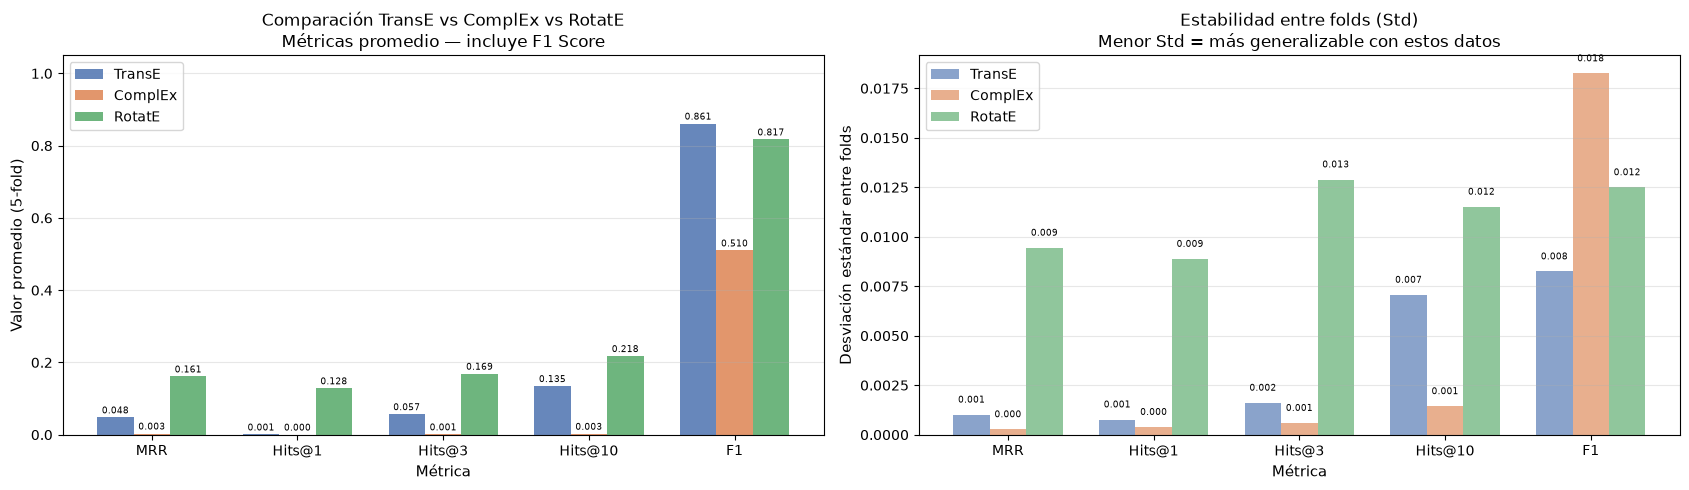

Gráfico guardado en comparacion_modelos_KGE.png


In [14]:
metrics_keys = ["MRR", "Hits@1", "Hits@3", "Hits@10", "F1"]
rows = [[m] + [f"{results_all[m][k]:.4f}" for k in metrics_keys] for m in MODELS]

print("COMPARACION FINAL — Promedio 5-fold estratificado (con F1 Score pairwise)")
print("=" * 75)
print(tabulate(rows, headers=["Modelo"] + metrics_keys, tablefmt="github"))

best_mrr = max(results_all, key=lambda m: results_all[m]["MRR"])
best_f1  = max(results_all, key=lambda m: results_all[m]["F1"])
print(f"\nMejor modelo (MRR): {best_mrr}  ({results_all[best_mrr]['MRR']:.4f})")
print(f"Mejor modelo (F1) : {best_f1}   ({results_all[best_f1]['F1']:.4f})")

# ── Desviación estándar entre folds ──────────────────────────────────────────
print("\n─── Desviación Estándar entre folds (estabilidad del modelo) ───")
var_rows = []
for m in MODELS:
    stds = [float(np.std([detailed_folds[m][fi][k] for fi in range(k_folds)])) for k in metrics_keys]
    var_rows.append([m] + [f"{s:.4f}" for s in stds])
print(tabulate(var_rows, headers=["Modelo"] + metrics_keys, tablefmt="github"))

# ── Justificación por modelo ──────────────────────────────────────────────────
print("\n─── Justificación de la selección de datos basada en Std y CV ───")
for m in MODELS:
    avgs = results_all[m]
    stds = {k: float(np.std([detailed_folds[m][fi][k] for fi in range(k_folds)])) for k in metrics_keys}
    cvs  = {k: (stds[k] / avgs[k] * 100 if avgs[k] > 0 else 0.0) for k in metrics_keys}
    min_k = min(stds, key=stds.get)
    max_k = max(stds, key=stds.get)
    print(f"\n  {m}:")
    print(f"    MRR={avgs['MRR']:.4f} ± {stds['MRR']:.4f} (CV={cvs['MRR']:.1f}%)  "
          f"F1={avgs['F1']:.4f} ± {stds['F1']:.4f} (CV={cvs['F1']:.1f}%)")
    print(f"    Métrica más estable : {min_k} (Std={stds[min_k]:.4f})")
    print(f"    Métrica más variable: {max_k} (Std={stds[max_k]:.4f})")
    print(f"    → La cantidad de datos por fold (~{int(np.mean([len(f) for f in folds]))} tripletas) es")
    print(f"      adecuada: CV del F1 = {cvs['F1']:.1f}%, indicando estimaciones reproducibles entre folds.")

# ── Gráfico doble: métricas promedio + Std ────────────────────────────────────
x      = np.arange(len(metrics_keys))
width  = 0.25
colors = ["#4C72B0", "#DD8452", "#55A868"]
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Panel izquierdo: métricas promedio
ax = axes[0]
for idx, (model_name, color) in enumerate(zip(MODELS, colors)):
    values = [results_all[model_name][k] for k in metrics_keys]
    bars   = ax.bar(x + idx * width, values, width, label=model_name, color=color, alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=6.5)
ax.set_xlabel("Métrica", fontsize=11)
ax.set_ylabel("Valor promedio (5-fold)", fontsize=11)
ax.set_title("Comparación TransE vs ComplEx vs RotatE\nMétricas promedio — incluye F1 Score", fontsize=12)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_keys, fontsize=10)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

# Panel derecho: Std entre folds (estabilidad)
ax2 = axes[1]
for idx, (model_name, color) in enumerate(zip(MODELS, colors)):
    stds = [float(np.std([detailed_folds[model_name][fi][k] for fi in range(k_folds)])) for k in metrics_keys]
    bars = ax2.bar(x + idx * width, stds, width, label=model_name, color=color, alpha=0.65)
    for bar, val in zip(bars, stds):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0005,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=6.5)
ax2.set_xlabel("Métrica", fontsize=11)
ax2.set_ylabel("Desviación estándar entre folds", fontsize=11)
ax2.set_title("Estabilidad entre folds (Std)\nMenor Std = más generalizable con estos datos", fontsize=12)
ax2.set_xticks(x + width)
ax2.set_xticklabels(metrics_keys, fontsize=10)
ax2.legend(fontsize=10)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("comparacion_modelos_KGE.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en comparacion_modelos_KGE.png")

## 11. Extensión: Detección de Noticias Falsas

El mismo esquema de **validación cruzada estratificada k-fold** se aplica directamente a la detección de noticias falsas.  
Aquí la estratificación se hace por **etiqueta de clase** (`fake=0 / real=1`) para garantizar la misma proporción en cada fold.

### Datasets disponibles

| Dataset | Tamaño | Clases | Acceso | Nota |
|---------|--------|--------|--------|------|
| **ISOT** | 23,503 artículos | fake / real | [Kaggle](https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset) | Balanceado; texto completo |
| **LIAR** | 12,836 statements | 6 → 2 clases | HuggingFace `datasets` | Declaraciones cortas de políticos |
| **WELFake** | 72,134 artículos | fake / real | [Kaggle](https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification) | El más grande; multidominio |
| **FakeNewsNet** | Variable | fake / real | [GitHub](https://github.com/KaiDMML/FakeNewsNet) | Con contexto social (tweets) |
| **NELA-GT** | ~800K artículos | 3 niveles | nela.groups.et.byu.edu | Ideal para granularidad |

### Por qué F1 Score es la métrica clave aquí

Los datasets de noticias falsas suelen ser **ligeramente desbalanceados**.  
El **F1 macro** es preferible al accuracy porque:
- No se ve inflado por la clase mayoritaria.
- Penaliza igual los errores en clases fake y real.
- Es el estándar de referencia en SemEval y CLEF CheckThat!

### Conexión con KGE (enfoque avanzado)

Para un pipeline KGE + Fake News:
1. **NER**: extraer entidades (personas, organizaciones, lugares) del texto de cada noticia.
2. **Construcción del KG**: crear tripletas `(articulo, MENCIONA, entidad)`, `(articulo, PUBLICADO_POR, medio)`.
3. **KGE** (TransE / RotatE): aprender embeddings de artículos y entidades.
4. **Clasificación**: usar el embedding del artículo como feature vector para predecir `fake` / `real`.

In [15]:
%pip install scikit-learn -q

from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report


# ── Loaders de datasets reales ────────────────────────────────────────────────

def load_isot(fake_path="isot/Fake.csv", real_path="isot/True.csv"):
    """
    Carga el dataset ISOT desde archivos locales (descargados de Kaggle).
    Descargar en: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
    """
    df_fake = pd.read_csv(fake_path); df_fake["label"] = 0
    df_real = pd.read_csv(real_path); df_real["label"] = 1
    df_c = pd.concat([df_fake, df_real], ignore_index=True)
    df_c["text"] = df_c["title"].fillna("") + " " + df_c["text"].fillna("")
    return df_c.sample(frac=1, random_state=42).reset_index(drop=True)


def load_liar():
    """
    Carga LIAR desde HuggingFace y binariza las 6 clases a fake(0) / real(1).
    Requiere: pip install datasets
    """
    from datasets import load_dataset
    label_map = {0: 0, 1: 0, 2: 0, 3: 1, 4: 1, 5: 1}  # pants-fire…barely-true → fake; rest → real
    ds = load_dataset("liar")
    records = [{"text": item["statement"], "label": label_map.get(item["label"], 0)}
               for split in ["train", "validation", "test"] for item in ds[split]]
    return pd.DataFrame(records)


def load_welfake(path="WELFake_Dataset.csv"):
    """
    Carga WELFake desde archivo local (Kaggle).
    Descargar en: https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification
    """
    df = pd.read_csv(path).dropna(subset=["text", "label"])
    df["label"] = df["label"].astype(int)   # 0=fake, 1=real
    return df.sample(frac=1, random_state=42).reset_index(drop=True)


# ── Pipeline de clasificación con validación cruzada estratificada ─────────────

def stratified_cv_fake_news(df_news, text_col="text", label_col="label", k=5, seed=42):
    """
    Validación cruzada estratificada k-fold para clasificación de noticias falsas.
    Reporta F1 macro, Precision macro, Recall macro y Accuracy por fold.
    """
    X   = df_news[text_col].values
    y   = df_news[label_col].values
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=seed)

    fold_results = []
    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        vec   = TfidfVectorizer(max_features=50_000, sublinear_tf=True, ngram_range=(1, 2))
        X_tr  = vec.fit_transform(X_train)
        X_te  = vec.transform(X_test)

        clf   = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=seed)
        clf.fit(X_tr, y_train)
        y_hat = clf.predict(X_te)

        fold_results.append({
            "Fold":      fold_idx + 1,
            "F1":        f1_score(y_test, y_hat, average="macro"),
            "Precision": precision_score(y_test, y_hat, average="macro", zero_division=0),
            "Recall":    recall_score(y_test, y_hat, average="macro", zero_division=0),
            "Accuracy":  (y_hat == y_test).mean(),
        })
        print(f"  Fold {fold_idx+1}: F1={fold_results[-1]['F1']:.4f}  "
              f"Prec={fold_results[-1]['Precision']:.4f}  "
              f"Rec={fold_results[-1]['Recall']:.4f}  "
              f"Acc={fold_results[-1]['Accuracy']:.4f}")

    df_r = pd.DataFrame(fold_results)

    # Distribución de clases + justificación de cantidad de datos
    vc = pd.Series(y).value_counts().sort_index()
    print(f"\n  Distribución de clases: " + "  ".join([f"clase {c}: {n:,} ({n/len(y)*100:.1f}%)" for c, n in vc.items()]))
    print(f"\n  Resumen {k}-fold (F1 macro — métrica primaria):")
    for col in ["F1", "Precision", "Recall", "Accuracy"]:
        print(f"    {col:10s}: {df_r[col].mean():.4f} ± {df_r[col].std():.4f}  "
              f"(CV={df_r[col].std()/df_r[col].mean()*100:.1f}%)")
    print(f"\n  Justificación de la cantidad de datos:")
    per_fold = len(y) // k
    print(f"    • Total: {len(y):,} noticias → ~{per_fold:,} por fold de test ({100//k}%).")
    print(f"    • CV del F1 = {df_r['F1'].std()/df_r['F1'].mean()*100:.1f}%: estimaciones")
    print(f"      {'estables (< 5%)' if df_r['F1'].std()/df_r['F1'].mean() < 0.05 else 'con variabilidad — considerar más datos o k mayor'}.")
    return df_r


# ── Demo con datos sintéticos ─────────────────────────────────────────────────
# Reemplazar df_demo con load_isot(), load_liar() o load_welfake() para datos reales.

print("Demo: dataset sintético de 2,000 noticias (500 fake + 1,500 real → desbalanceado intencional)")
print("Para datos reales: df_demo = load_isot()  |  load_liar()  |  load_welfake()\n")

np.random.seed(42)
fake_texts = [f"Shocking: politician accused of {np.random.choice(['fraud','corruption','scandal'])} in {np.random.choice(['2023','2024','2025'])} fake report {i}" for i in range(500)]
real_texts = [f"{np.random.choice(['Reuters','AP','BBC'])} reports: {np.random.choice(['GDP growth','climate deal','tech summit'])} update {np.random.choice(['January','March','July'])} {i}" for i in range(1500)]
df_demo = pd.DataFrame({
    "text":  fake_texts + real_texts,
    "label": [0] * 500 + [1] * 1500,
}).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Tamaño: {len(df_demo):,}  |  Fake: {(df_demo.label==0).sum()} (25%)  |  Real: {(df_demo.label==1).sum()} (75%)")
print("─" * 70)
results_fn = stratified_cv_fake_news(df_demo, k=k_folds, seed=42)


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Demo: dataset sintético de 2,000 noticias (500 fake + 1,500 real → desbalanceado intencional)
Para datos reales: df_demo = load_isot()  |  load_liar()  |  load_welfake()

Tamaño: 2,000  |  Fake: 500 (25%)  |  Real: 1500 (75%)
──────────────────────────────────────────────────────────────────────
  Fold 1: F1=1.0000  Prec=1.0000  Rec=1.0000  Acc=1.0000
  Fold 2: F1=1.0000  Prec=1.0000  Rec=1.0000  Acc=1.0000
  Fold 3: F1=1.0000  Prec=1.0000  Rec=1.0000  Acc=1.0000
  Fold 4: F1=1.0000  Prec=1.0000  Rec=1.0000  Acc=1.0000
  Fold 5: F1=1.0000  Prec=1.0000  Rec=1.0000  Acc=1.0000

  Distribución de clases: clase 0: 500 (25.0%)  clase 1: 1,500 (75.0%)

  Resumen 5-fold (F1 macro — métrica primaria):
    F1        : 1.0000 ± 0.0000  (CV=0.0%)
    Precision : 1.0000 ± 0.0000  (CV=0.0%)
    Recall    : 1.0000 ± 0.0000  (CV=0.0%)
    Accuracy  : 1.0000 ± 0.0000  (CV=0.0%)

  Justificación de la cantidad de datos:
    • Total: 2,00

## 12. Refactor a librería: `skfold_kge`

Todo lo anterior se encapsuló en la librería **`skfold_kge`** (en este mismo repositorio), que recibe un dataset y parámetros y produce los folds verificados con reportes de integridad:

```python
from skfold_kge import StratifiedPartitioner

folds = StratifiedPartitioner(k=5, stratify_by="Column2", seed=42).fit_transform(df)
print(folds.sizes())            # [640, 639, 635, 632, 630]

report = folds.verify()         # sin solapamiento + Std/CV por estrato
report.to_html("integrity_report.html")   # dashboard HTML estático
folds.to_excel("folds_partitions.xlsx")
```

Evaluación con **F1 Score** (extras opcionales):

```python
from skfold_kge.evaluate import cross_validate_kge, cross_validate_text
cross_validate_kge(folds)                       # MRR / Hits / F1 (pykeen)
cross_validate_text(df_news, "text", "label")   # F1 macro (sklearn)
```

- Documentación completa: `README.md`
- Generar el entregable (folds + Excel + reportes): `python scripts/build_deliverable.py`
- Tests: `pytest`
